# 01 — Data Assessing
Inventarisasi dataset, struktur anotasi YOLO/COCO, dan pengecekan awal kualitas data.

## Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Arahkan root path ke parent folder agar bisa mengimpor modul lokal (src, config)
sys.path.insert(0, str(Path.cwd().parent))

# Import konfigurasi terbaru yang sudah kita perbaiki
from config.paths import BASE_DATA_DIR, DATASETS, PLOT_CONFIG, FIGURES_DIR
from src.data_loader import YOLOLoader

# Terapkan tema visual (dark mode) agar selaras dengan Streamlit
plt.style.use(PLOT_CONFIG['style'])
sns.set_palette(PLOT_CONFIG['palette'])

print("[INFO] Lingkungan kerja Jupyter berhasil disiapkan!")

[INFO] Lingkungan kerja Jupyter berhasil disiapkan!


## 1. Inventarisasi File

In [2]:
print("=== INVENTARISASI DATASET MENTAH (TRAIN & VALID) ===\n")

for ds_name, config in DATASETS.items():
    base_path = config["path"]
    print(f"📦 Dataset: {ds_name.upper()}")
    
    if not base_path.exists():
        print(f"  [X] Folder {base_path} tidak ditemukan! Pastikan data sudah diunduh.")
        print("-" * 40)
        continue
        
    total_images = 0
    total_labels = 0
    
    # Sapu folder train dan valid
    for split in ["train", "valid"]:
        img_dir = base_path / split / "images"
        lbl_dir = base_path / split / "labels"
        
        if img_dir.exists() and lbl_dir.exists():
            n_img = len(list(img_dir.glob("*.*")))
            n_lbl = len(list(lbl_dir.glob("*.txt")))
            total_images += n_img
            total_labels += n_lbl
            print(f"  -> {split.capitalize():<6}: {n_img:,} gambar | {n_lbl:,} file anotasi YOLO")
            
    print(f"  => Total  : {total_images:,} gambar | {total_labels:,} file anotasi YOLO\n")

=== INVENTARISASI DATASET MENTAH (TRAIN & VALID) ===

📦 Dataset: FALL_DETECTION
  -> Train : 24,188 gambar | 24,188 file anotasi YOLO
  -> Valid : 832 gambar | 832 file anotasi YOLO
  => Total  : 25,020 gambar | 25,020 file anotasi YOLO

📦 Dataset: SMOKE_FIRE
  -> Train : 1,653 gambar | 1,653 file anotasi YOLO
  -> Valid : 157 gambar | 157 file anotasi YOLO
  => Total  : 1,810 gambar | 1,810 file anotasi YOLO

📦 Dataset: PERSON_DETECTION
  -> Train : 28,338 gambar | 28,338 file anotasi YOLO
  -> Valid : 352 gambar | 352 file anotasi YOLO
  => Total  : 28,690 gambar | 28,690 file anotasi YOLO



## 2. Sample Label

In [3]:
# Mengambil sampel file label YOLO dari dataset Fall Detection
sample_lbl_dir = DATASETS["fall_detection"]["path"] / "train" / "labels"

print("=== SAMPEL ISI ANOTASI YOLO (FALL DETECTION) ===")
if sample_lbl_dir.exists():
    label_files = list(sample_lbl_dir.glob("*.txt"))
    for lbl in label_files[:3]:
        print(f"\n--- File: {lbl.name} ---")
        print(lbl.read_text().strip())
else:
    print("[WARNING] Folder label train tidak ditemukan.")

=== SAMPEL ISI ANOTASI YOLO (FALL DETECTION) ===

--- File: 0_png.rf.9d8c0c3b2d7e0a9087209ab517f49e1e.txt ---
2 0.17734375 0.38828125 0.29228515625 0.63603515625

--- File: 0_png.rf.d0c7845e7ce7c59e9f385943a94b522b.txt ---
2 0.17734375 0.38828125 0.29228515625 0.63603515625

--- File: 0_png.rf.d180efef87d5e74b7bfe46de5ba258c5.txt ---
2 0.17734375 0.38828125 0.29228515625 0.63603515625


## 3. Load Dataset

In [5]:
# ==========================================
# CELL 4: LOAD DATASET KE PANDAS
# ==========================================
from src.data_loader import load_all_datasets

print("=== MEMUAT SELURUH DATASET YOLO ===")
# Alih-alih memanggil YOLOLoader secara manual, kita gunakan mesin global 
# yang akan menyapu bersih folder 'train' dan 'valid' sekaligus
df_raw = load_all_datasets(DATASETS)

print(f"\n[INFO] Bentuk Data (Shape): {df_raw.shape}")
display(df_raw.head())

=== MEMUAT SELURUH DATASET YOLO ===

📥 Inisialisasi Loader untuk: FALL_DETECTION


Memuat human_fall/train: 100%|██████████| 24188/24188 [10:41<00:00, 37.69it/s]


  ✓ Berhasil memuat 25,241 baris dari folder train.


Memuat human_fall/valid: 100%|██████████| 832/832 [00:27<00:00, 30.15it/s]


  ✓ Berhasil memuat 854 baris dari folder valid.


...

Memuat person_detection/valid: 100%|██████████| 352/352 [00:14<00:00, 24.71it/s]


  ✓ Berhasil memuat 1,137 baris dari folder valid.


Memuat person_detection/test: 100%|██████████| 102/102 [00:03<00:00, 26.66it/s]


  ✓ Berhasil memuat 266 baris dari folder test.

✅ PROSES SELESAI: Menghasilkan 146,974 kotak anotasi (BBox) dari 56,593 gambar unik.

[INFO] Bentuk Data (Shape): (146974, 16)


,dataset,split,image_id,image_path,label_path,img_exists,img_width,img_height,line_no,class_id,class_name,bbox_x_center,bbox_y_center,bbox_width,bbox_height,format
0,human_fall,train,0_png.rf.9d8c0c3b2d7e0a9087209ab517f49e1e,d:\DBS Capstone Code\ds_workspace_2\safewatch-...,d:\DBS Capstone Code\ds_workspace_2\safewatch-...,True,640,640,1,2,Person,0.177344,0.388281,0.292285,0.636035,yolo
1,human_fall,train,0_png.rf.d0c7845e7ce7c59e9f385943a94b522b,d:\DBS Capstone Code\ds_workspace_2\safewatch-...,d:\DBS Capstone Code\ds_workspace_2\safewatch-...,True,640,640,1,2,Person,0.177344,0.388281,0.292285,0.636035,yolo
2,human_fall,train,0_png.rf.d180efef87d5e74b7bfe46de5ba258c5,d:\DBS Capstone Code\ds_workspace_2\safewatch-...,d:\DBS Capstone Code\ds_workspace_2\safewatch-...,True,640,640,1,2,Person,0.177344,0.388281,0.292285,0.636035,yolo
3,human_fall,train,100_png.rf.11548409330c6c7805f69303c21440dd,d:\DBS Capstone Code\ds_workspace_2\safewatch-...,d:\DBS Capstone Code\ds_workspace_2\safewatch-...,True,640,640,1,2,Person,0.310156,0.467969,0.173437,0.442285,yolo
4,human_fall,train,100_png.rf.363f983ca3395b0e5f9575d7eb2e8f7a,d:\DBS Capstone Code\ds_workspace_2\safewatch-...,d:\DBS Capstone Code\ds_workspace_2\safewatch-...,True,640,640,1,2,Person,0.310156,0.467969,0.173437,0.442285,yolo


## 4. Distribusi Awal Kelas

[SUKSES] Grafik berhasil diekspor ke: d:\DBS Capstone Code\ds_workspace_2\safewatch-main\reports\figures\01_class_distribution_raw.png


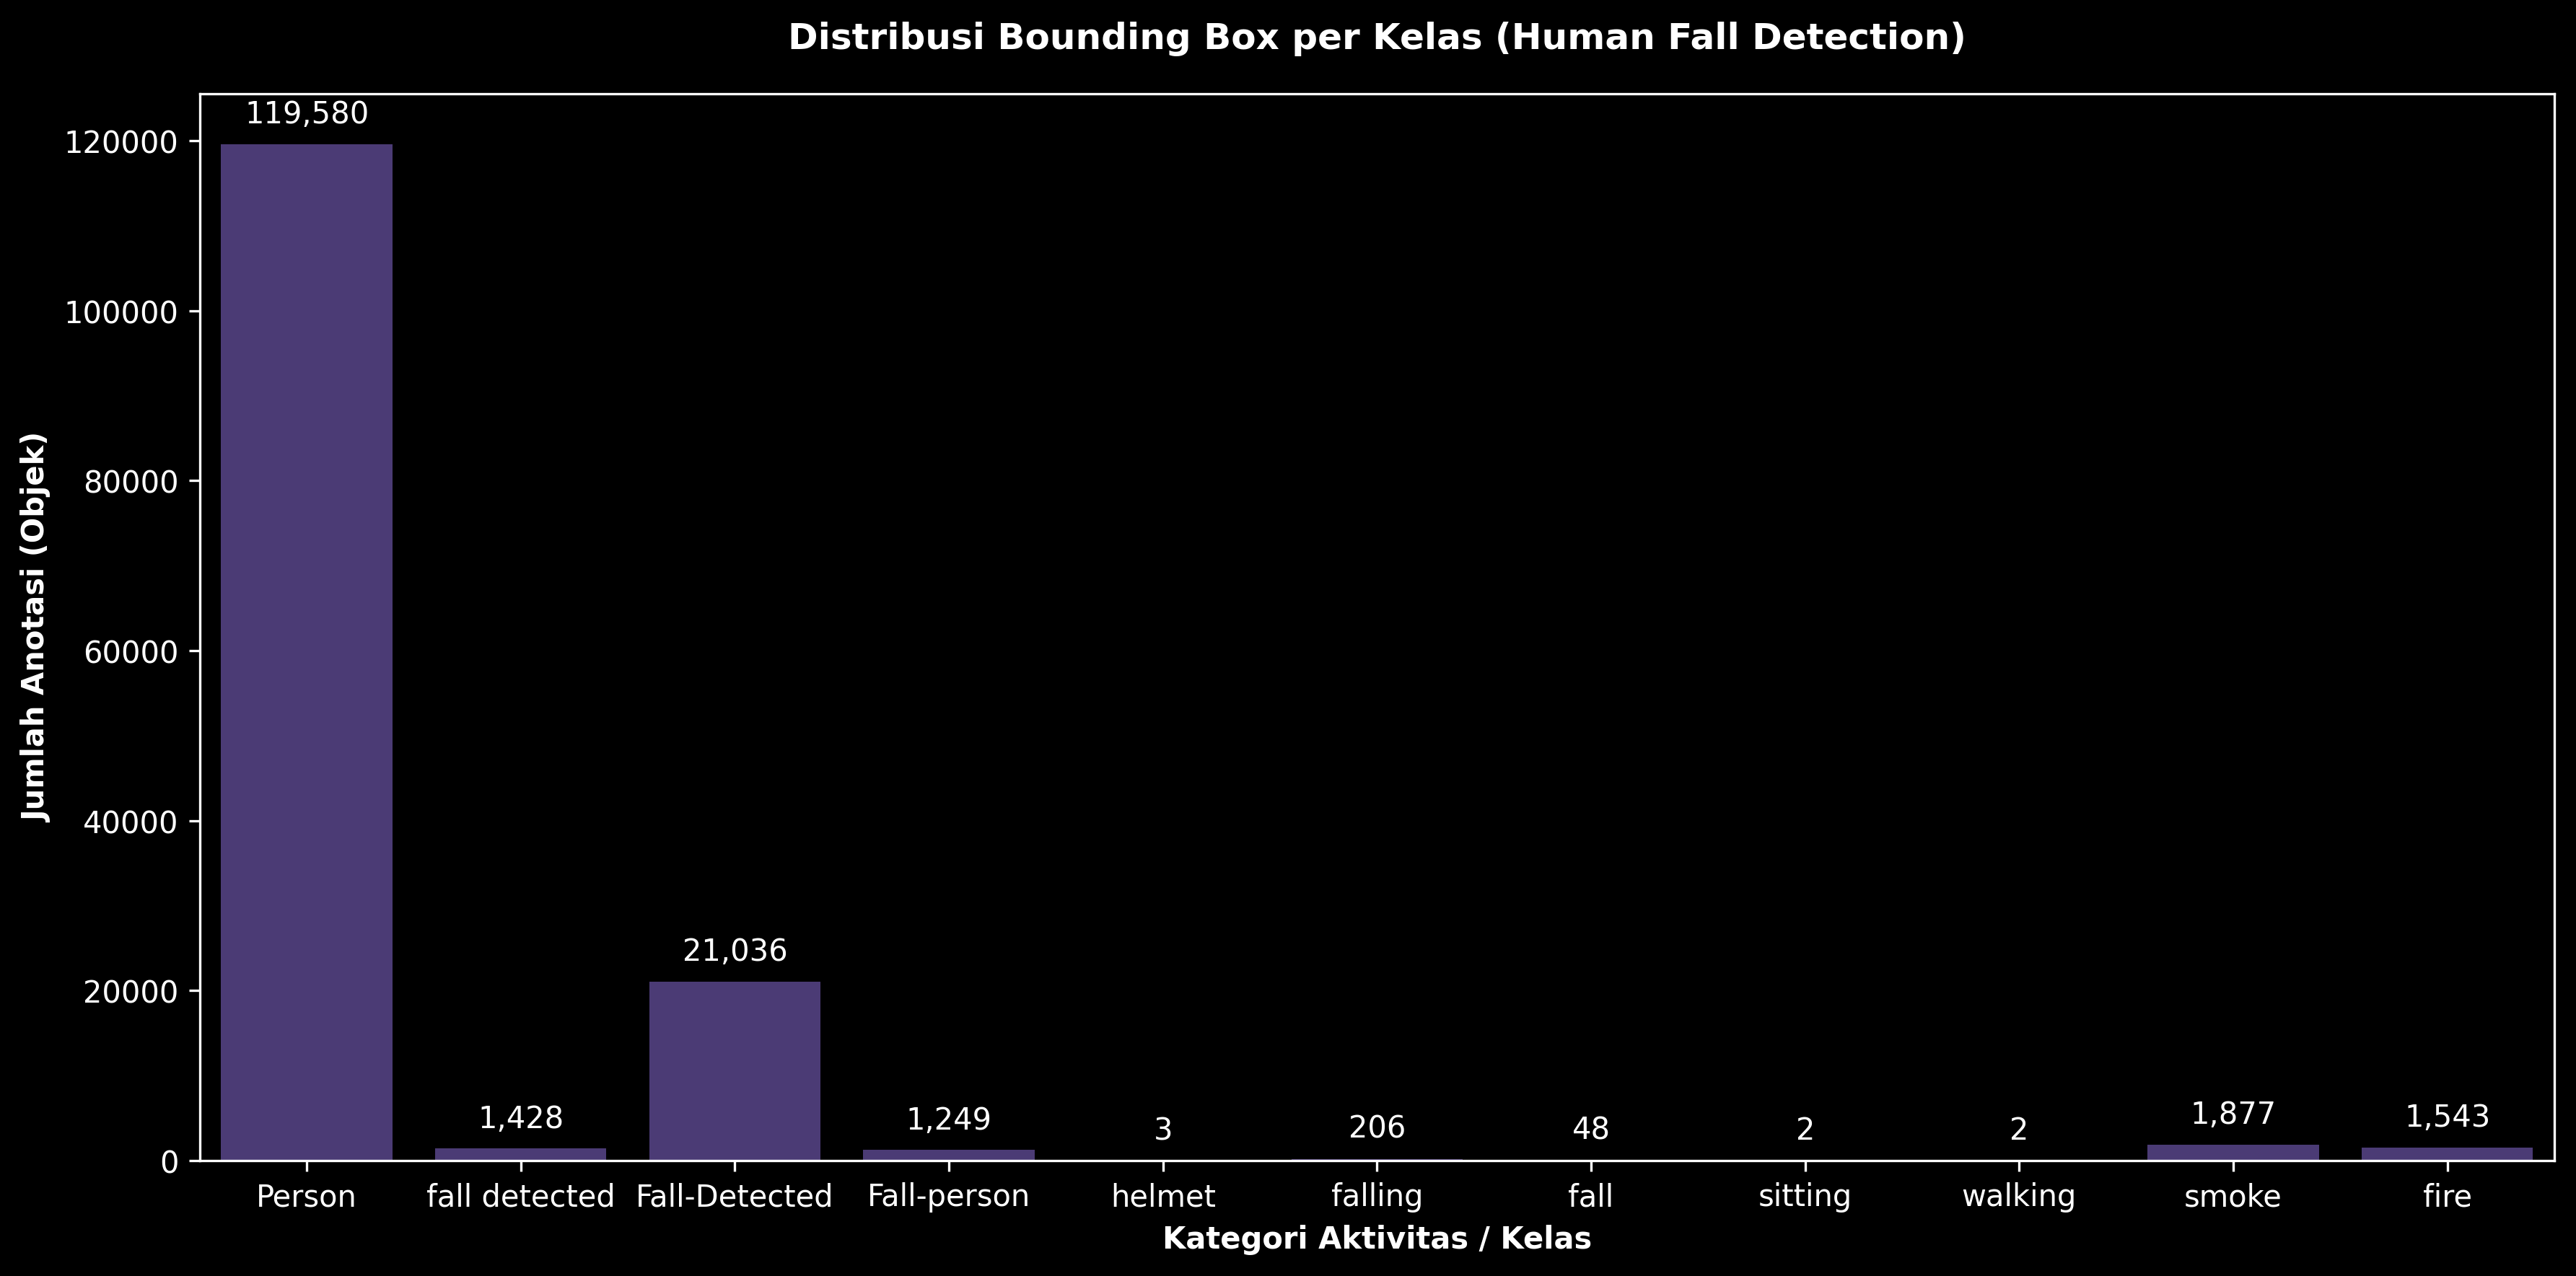

In [6]:
plt.figure(figsize=PLOT_CONFIG['figsize'], dpi=PLOT_CONFIG['dpi'])

# Visualisasi distribusi jumlah objek (Bounding Box) per kelas menggunakan Seaborn
# Sesuaikan nama kolom "class_id" atau "class_name" dengan output dari loader-mu
ax = sns.countplot(data=df_raw, x="class_name") 

plt.title("Distribusi Bounding Box per Kelas (Human Fall Detection)", pad=15, fontweight='bold')
plt.xlabel("Kategori Aktivitas / Kelas", fontweight='bold')
plt.ylabel("Jumlah Anotasi (Objek)", fontweight='bold')

# Menambahkan angka di atas batang diagram
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, color='white', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()

# Simpan otomatis ke folder laporan menggunakan paths yang aman
output_plot = FIGURES_DIR / "01_class_distribution_raw.png"
plt.savefig(output_plot)
print(f"[SUKSES] Grafik berhasil diekspor ke: {output_plot}")

plt.show()